In [82]:
import os
import random
import glob
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [83]:
# 학습된 모델 경로
MODEL_PATH = r'C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\best_cnn_model_1000(2).keras'

# 스펙토그램 이미지 폴더
SPEC_DIR = r'C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\spectrogram_data'

# 이미지 크기
IMG_HEIGHT = 224
IMG_WIDTH = 224

# 클래스 이름
CLASS_NAMES = ['Non_Hornet', 'Hornet']

# 랜덤 샘플 개수
NUM_SAMPLES = 5

In [84]:
model = load_model(MODEL_PATH)
print('모델 로드 완료')
model.summary()

모델 로드 완료


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,702,728 (151.45 MB)

 Trainable params: 13,234,242 (50.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,468,486 (100.97 MB)

In [85]:
model = load_model(MODEL_PATH)

dummy_input = np.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
_ = model(dummy_input)

print('모델 로드 완료')

모델 로드 완료


# 이미지 전처리 함수 셀

In [86]:
def load_and_preprocess_image(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# 마지막 레이어 찾기

In [87]:
import tensorflow as tf
import numpy as np

def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            print("사용되는 conv layer:", layer.name)
            return layer.name
    raise ValueError("Conv2D layer 없음")

In [88]:
dummy_input = np.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
_ = model(dummy_input)

dummy_input = np.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
dummy_output = model(dummy_input, training=False)

print("model.inputs:", model.inputs)
print("model.outputs:", model.outputs)
print("dummy_output shape:", dummy_output.shape)

last_conv_layer_name = get_last_conv_layer_name(model)
print("마지막 Conv 레이어:", last_conv_layer_name)

model.inputs: [<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer>]
model.outputs: [<KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1247>]
dummy_output shape: (1, 2)
사용되는 conv layer: conv2d_3
마지막 Conv 레이어: conv2d_3


In [89]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer))

0 conv2d <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
1 max_pooling2d <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'>
2 conv2d_1 <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
3 max_pooling2d_1 <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'>
4 conv2d_2 <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
5 max_pooling2d_2 <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'>
6 conv2d_3 <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
7 max_pooling2d_3 <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'>
8 flatten <class 'keras.src.layers.reshaping.flatten.Flatten'>
9 dense <class 'keras.src.layers.core.dense.Dense'>
10 dropout <class 'keras.src.layers.regularization.dropout.Dropout'>
11 dense_1 <class 'keras.src.layers.core.dense.Dense'>


# Grad-CAM heatmap 생성

In [90]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 마지막 conv layer 가져오기
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # 입력 -> 마지막 conv 출력까지의 모델
    last_conv_layer_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=last_conv_layer.output
    )

    # 마지막 conv layer 이후의 classifier 부분을 따로 실행
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input

    passed_last_conv = False
    for layer in model.layers:
        if layer.name == last_conv_layer_name:
            passed_last_conv = True
            continue
        if passed_last_conv:
            x = layer(x)

    classifier_model = tf.keras.models.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_layer_model(img_array, training=False)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs, training=False)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    if grads is None:
        raise ValueError('Grad-CAM gradient가 None입니다. 마지막 Conv 레이어 이름 또는 모델 구조를 다시 확인하세요.')

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(pred_index), predictions.numpy()[0]

# overlay용 함수

In [91]:
import matplotlib.cm as cm
from PIL import Image

def overlay_gradcam_on_image(img_path, heatmap, alpha=0.4):
    img = Image.open(img_path).convert('RGB').resize((IMG_WIDTH, IMG_HEIGHT))
    img = np.array(img)

    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = Image.fromarray((jet_heatmap * 255).astype(np.uint8))
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = np.array(jet_heatmap)

    overlay = np.uint8(np.clip(jet_heatmap * alpha + img, 0, 255))

    return img, jet_heatmap, overlay

사용되는 conv layer: conv2d_3


C:\Users\hoons\AppData\Local\Temp\ipykernel_8040\1717180204.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap('jet')


<Figure size 1800x2500 with 0 Axes>

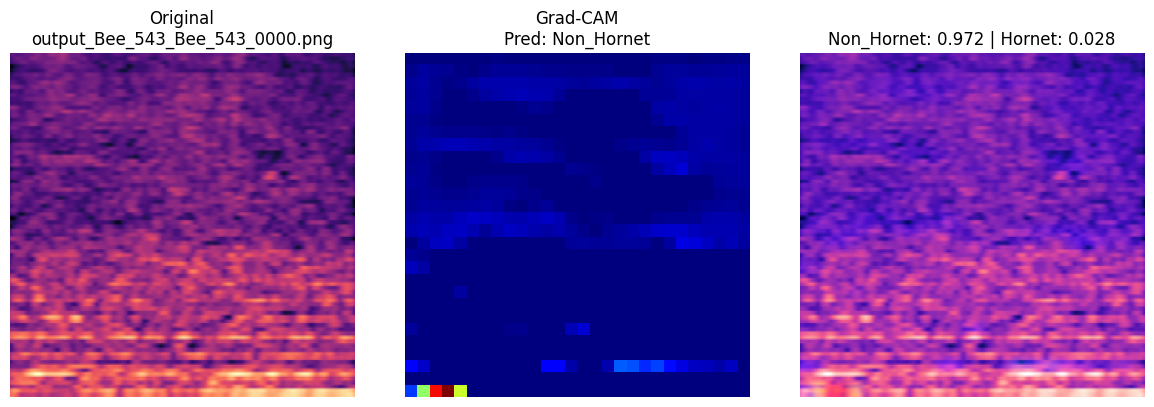

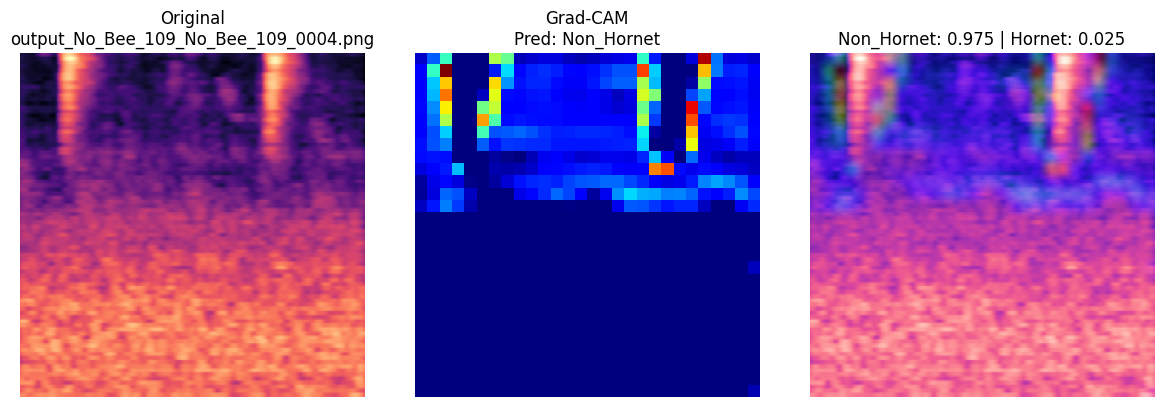

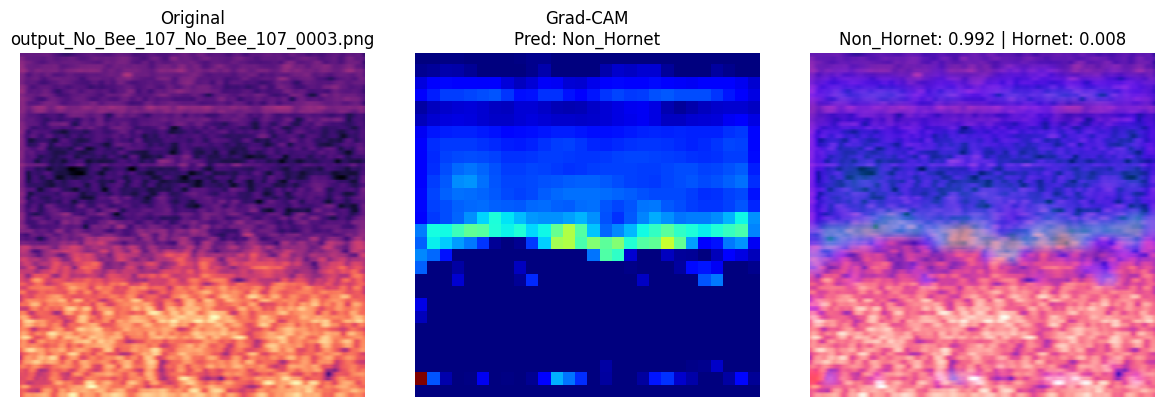

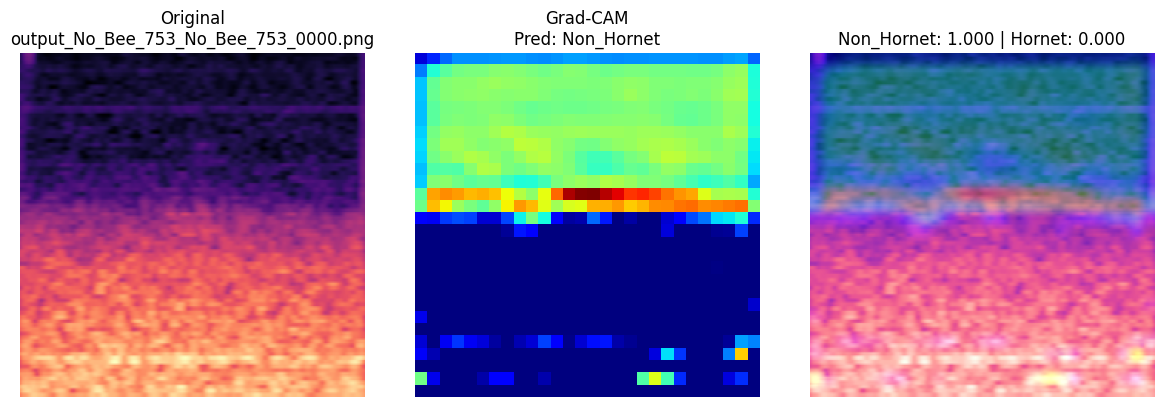

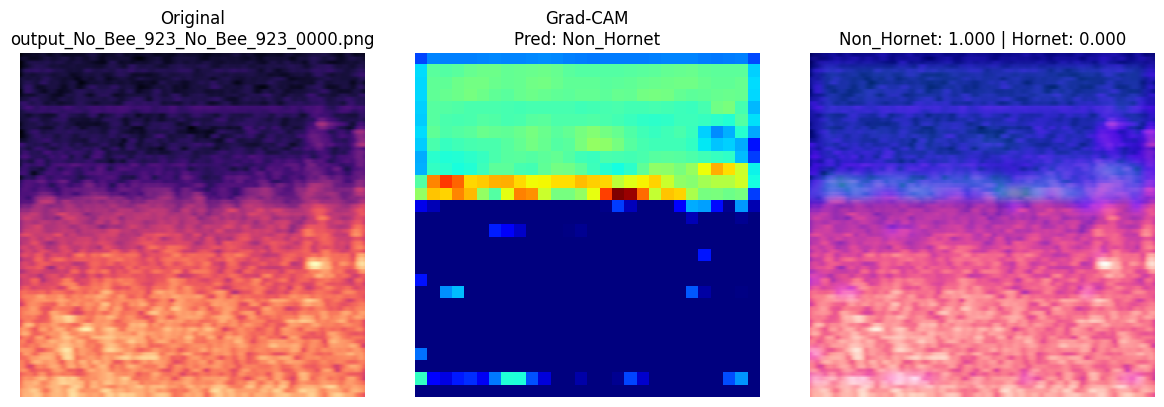

In [98]:
import matplotlib.pyplot as plt
import os
import random
import glob

NUM_SAMPLES = 5
CLASS_NAMES = ['Non_Hornet', 'Hornet']

all_image_paths = glob.glob(os.path.join(SPEC_DIR, '*', '*.png'))
sample_paths = random.sample(all_image_paths, min(NUM_SAMPLES, len(all_image_paths)))

last_conv_layer_name = get_last_conv_layer_name(model)

plt.figure(figsize=(18, 5 * len(sample_paths)))

for img_path in sample_paths:
    img_array = load_and_preprocess_image(img_path)

    heatmap, pred_index, pred_probs = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    original_img, heatmap_img, overlay_img = overlay_gradcam_on_image(img_path, heatmap)

    pred_class = CLASS_NAMES[pred_index]
    true_class = os.path.basename(os.path.dirname(img_path))
    file_name = os.path.basename(img_path)

    non_hornet_prob = pred_probs[0]
    hornet_prob = pred_probs[1]

    # 이미지 하나당 figure 새로 생성
    plt.figure(figsize=(12, 4))

    # 1. 원본
    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.axis('off')
    plt.title(f'Original\n{file_name}')

    # 2. heatmap
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.axis('off')
    plt.title(f'Grad-CAM\nPred: {pred_class}')

    # 3. overlay
    plt.subplot(1, 3, 3)
    plt.imshow(overlay_img)
    plt.axis('off')
    plt.title(f'Non_Hornet: {non_hornet_prob:.3f} | Hornet: {hornet_prob:.3f}')

    plt.tight_layout()
    plt.show()

In [99]:
bee_paths = glob.glob(os.path.join(SPEC_DIR, 'Non_Hornet', 'output_Bee_*.png'))
sample_paths = random.sample(bee_paths, min(NUM_SAMPLES, len(bee_paths)))

In [100]:
hornet_image_paths = glob.glob(os.path.join(SPEC_DIR, 'Hornet', '*.png'))
sample_paths = random.sample(hornet_image_paths, min(NUM_SAMPLES, len(hornet_image_paths)))

# 오답만 골라서 보고 싶으면

In [101]:
wrong_samples = []

all_image_paths = glob.glob(os.path.join(SPEC_DIR, '*', '*.png'))
random.shuffle(all_image_paths)

for img_path in all_image_paths:
    img_array = load_and_preprocess_image(img_path)
    pred = model.predict(img_array, verbose=0)[0]
    pred_index = np.argmax(pred)
    pred_class = CLASS_NAMES[pred_index]
    true_class = os.path.basename(os.path.dirname(img_path))

    if pred_class != true_class:
        wrong_samples.append(img_path)

    if len(wrong_samples) >= 5:
        break

sample_paths = wrong_samples

KeyboardInterrupt: 